In [80]:
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel,Field

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

from langchain_core.messages import HumanMessage, SystemMessage

from langchain_openai import ChatOpenAI

import os
import uuid

In [81]:
import os
from dotenv import load_dotenv
load_dotenv()
llm= ChatOpenAI(
    base_url= os.getenv("BASE_URL"),
    api_key= os.getenv("API_KEY"),
    model="openai/gpt-oss-20b",
    temperature=0
)

In [82]:
def create_ticket(issue:str,order_id:int):

    """
    Creates a new support ticket for a user.
    
    Args:
        issue: The issue description.
        order_id: The ID of the order (optional).
        
    Returns:
        A success message with the ticket number.
    """
    
    ticket_no=(
        "SUP-"+
        str(uuid.uuid4())[:8]
    )

    return (
        f"""
        Ticket created successfully

        Ticket:
        {ticket_no}

        Support team will contact you.
        """
    )

In [83]:
from generator import generate_rag_response
def handle_faq(question:str):

    """ 
    FAQ and company policies
    """ 

    response= generate_rag_response(
        question
    )
    return response

In [84]:
def track_order(order_id:int):
    """Track order using an order ID"""
    
    if order_id==345:
        return {
            "success":True,
            "product":"Asus TUF Gaming Laptop",
            "status":"Out for Delivery",
            "courier":"BlueDart",
            "tracking":"BLD445566",
            "delivery_date":"2026-05-17",
            "amount":68999
        }
    else:
        return "please enter valid order id"

In [85]:
def handle_refund(order_id:int):    

    """ 
    Handles refund requests for users.
    """
    refund_avilable=True
    if order_id==345:
        order_detals={"success":True,
            "product":"Asus TUF Gaming Laptop",
            "status":"Out for Delivery",
            "courier":"BlueDart",
            "tracking":"BLD445566",
            "delivery_date":"2026-05-17",
            "amount":68999}
        if refund_avilable==True:
            return (
                "Refund request created. "
                "Pickup will be scheduled "
                "within 24 hours.",
            )
        else:
            return "You Can Not Now Refund Beacuse Refund Policy Is 7 Days"
    else:
        return "please enter valid order id"

In [86]:
class State(TypedDict):

    messages:Annotated[
        list,
        add_messages
    ]
    intent:str
    result:str

In [87]:
from pydantic import BaseModel,Field
from typing import Literal

class IntentSchema(BaseModel):

    intent:Literal[
        "track_order",
        "refund",
        "complaint",
        "faq",
        "payment",
        "multi_intent"
    ]

    reason:str=Field(
        description="reason for selection"
    )


intent_llm=llm.with_structured_output(IntentSchema)

In [88]:
def detect_intent(
    state:State
):

    user_query=(
        state["messages"][-1]
        .content
    )

    prompt=f"""
You are ecommerce intent classifier.

Allowed intents:

track_order
refund
complaint
faq
payment
multi_intent

Rules:

Tracking related →
track_order

Refund related →
refund

Complaint or issue →
complaint

Policies/questions →
faq

Payment issue →
payment

More than one request →
multi_intent


Query:

{user_query}
"""

    response=(
        intent_llm.invoke(
            prompt
        )
    )

    print(response)

    return {

        "intent":
        response.intent
    }

In [ ]:
def track_node(
    state:State
):

    return {

        "result":
        "Order delayed"
    }

In [ ]:
def refund_node(
    state:State
):

    return {

        "result":
        "Refund initiated"
    }

In [ ]:
def complaint_node(
    state:State
):

    return {

        "result":
        "Complaint ticket created"
    }

In [ ]:
def faq_node(
    state:State
):

    return {

        "result":
        "Answer from RAG"
    }

In [ ]:
def payment_node(
    state:State
):

    return {

        "result":
        "Payment verified"
    }

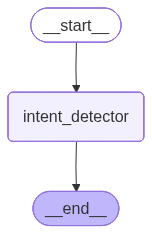

In [89]:
builder = StateGraph(State)
builder.add_node(
    "intent_detector",
    detect_intent
)
builder.add_edge(START,"intent_detector")
builder.add_edge("intent_detector", END)

chatbot= builder.compile()
chatbot


In [92]:
res= chatbot.invoke({"messages":"Track order 345"})

res

intent='track_order' reason='User wants to track order 345'


{'messages': [HumanMessage(content='Track order 345', additional_kwargs={}, response_metadata={}, id='8586fad3-7218-44d0-a097-0ed81ed3989a')],
 'intent': 'track_order'}

In [ ]:
def router(state):

    return state["intent"]

In [ ]:
graph = StateGraph(ChatState)
builder.add_node(
    "intent_detector",
    detect_intent
)

builder.add_conditional_edges(
    "intent_detector",
    router,
    {
        "track_order":"track_node",
        "refund":"refund_node",
        "complaint":"complaint_node",
        "faq":"faq_node",
        "payment":"payment_node",
        "multi_intent":"planner_node"
    }
)


from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

chatbot = graph.compile(
    checkpointer=memory
)

In [60]:
config = {
    "configurable":{
        "thread_id":"harsh"
    }
}

In [61]:
from langchain_core.messages import HumanMessage

response = chatbot.invoke(
    {
        "messages": [
            HumanMessage(content="Track order 345, tell me shipping policy, and if delayed create complaint")
        ]
    },
    config=config
        
)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 534, 'total_tokens': 584, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.052816962, 'prompt_time': 0.034516713, 'completion_time': 0.064266694, 'total_time': 0.098783407}, 'model_provider': 'openai', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'id': 'chatcmpl-3e4800ad-351b-4a6e-bf51-a0d8575a4585', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019e2fd7-4f23-7740-b5c9-d7c331de16d0-0' tool_calls=[{'name': 'track_order', 'args': {'order_id': 345}, 'id': 'xnqdvck76', 'type': 'tool_call'}, {'name': 'handle_faq', 'args': {'question': 'Shipping policy'}, 'id': 'kyhcy7z41', 'type': 'tool_call'}, {'name': 'create_ticket', 'args': {'issue': 'Order ', 'order_id': 345}, 'id': 'zn5t2e20v', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 534

In [63]:
print(response["messages"][-1].content)

If the order status is not "Out for Delivery" and is delayed, the assistant will create a complaint and provide the shipping policy.

If the order status is "Out for Delivery" but the user is not satisfied, the assistant will still create a complaint and provide the shipping policy.

If the order status is "Out for Delivery" and the user does not express any dissatisfaction, the assistant will not create a complaint but will still provide the shipping policy.

The assistant never invents IDs and always seeks additional information to create a complaint or provide the shipping policy.


In [62]:
import inspect
from generator import generate_rag_response

print(inspect.iscoroutinefunction(generate_rag_response))

False
